# 04 · Which funnel stage to invest in? — mediation (pathmc)

**The decision.** A fixed budget to split across the funnel —
**onboarding → engagement → activation → conversion**. Which stage gives the most leverage on
paid conversion, *respecting that effects cascade*? A dollar into onboarding doesn't just help
onboarding; it flows downstream. We need to trace those paths, decompose **direct vs indirect**
effect, and — crucially — know **how fragile the split is** to unmeasured confounding between a
mediator and the outcome (the classic mediation trap).

`pathmc` builds the chain as a structural causal model and computes **path-specific effects** by
propagating posterior draws through the intervened graph — the modern, uncertainty-aware
mediation analysis. 7-step contract.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 13

## 2 · Simulate a ground truth

A chain `onboarding_score → engagement → activated → converted`, with `channel_quality`
feeding engagement and activation. The planted structure gives a known **total** effect of
onboarding on conversion, split into paths — most flows through `engagement → activated`, a
little through `engagement → converted` directly.


In [2]:
df, true_effects = dgp.funnel(n=1000, seed=SEED)
print("TRUE effects of onboarding on conversion:")
for k, v in true_effects.items(): print(f"  {k:36s} {v:.2f}")
df.head()

TRUE effects of onboarding on conversion:
  indirect_via_engagement_activated    3.17
  indirect_via_engagement_only         0.77
  total                                3.94


,onboarding_score,channel_quality,engagement,activated,converted
0,0.864798,0.726815,2.576471,3.869429,4.870321
1,0.855303,0.790067,3.206651,5.673260,6.371102
2,0.811023,0.348493,2.493785,4.691864,5.394113
3,0.261446,0.465793,0.572682,1.261547,1.264003
4,0.077199,0.887974,1.520775,3.259916,3.146544


## 3 · Identify — direct vs indirect effects (NDE / NIE)

For a chain $X\to M\to Y$ the **total effect** decomposes into a **natural direct effect** and
**natural indirect effect** (Pearl):

$$\text{TE}=\text{NDE}+\text{NIE},\quad
\text{NDE}=\mathbb E[Y(1,M(0))-Y(0,M(0))],\quad
\text{NIE}=\mathbb E[Y(1,M(1))-Y(1,M(0))].$$

Under a linear SCM these are the **product-of-coefficients**: indirect $=a\cdot b$, direct $=c$.
The **proportion mediated** $=\text{NIE}/\text{TE}$ tells you how much of onboarding's value is
"really" downstream engagement/activation. `pathmc` computes path-specific effects for the full
chain by simulating through the intervened graph.

**Assumptions (stronger than a single-link analysis):** no unmeasured confounding of $X\!-\!Y$,
$M\!-\!Y$, *and* $X\!-\!M$, plus the **cross-world** condition that no $M\!-\!Y$ confounder is
itself affected by $X$. Natural effects are *not identified* if that last one fails — and the
$M\!-\!Y$ confounding assumption is the one most likely to break, so we stress-test it in step 6.


## 4 · Estimate — fit the chain and query every path

In [3]:
spec = '''
engagement ~ e_on*onboarding_score + e_ch*channel_quality
activated  ~ a_eng*engagement + a_ch*channel_quality
converted  ~ c_act*activated + c_eng*engagement
'''
m = pathmc.model(spec, data=df)
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
m.effects_summary().round(3)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_engagement, beta_engagement, beta_converted, sigma_activated, beta_activated, sigma_converted]


Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%
name,,,,
e_on,2.150,0.042,2.073,2.226
e_ch,1.131,0.043,1.043,1.207
a_eng,1.616,0.018,1.584,1.652
a_ch,0.592,0.054,0.490,0.690
c_act,0.896,0.022,0.857,0.940
c_eng,0.361,0.040,0.286,0.430


## 5 · Validate — recover the total, the paths, and the proportion mediated

In [4]:
def get_draws(res):
    d = res.draws
    return np.asarray(d() if callable(d) else d)

total_d = get_draws(m.ate("converted", "onboarding_score"))
via_act = get_draws(m.effect("onboarding_score -> engagement -> activated -> converted"))
via_eng = get_draws(m.effect("onboarding_score -> engagement -> converted"))
indirect_d = via_act + via_eng
prop_mediated = indirect_d / total_d

def line(lbl, d, truth):
    print(f"{lbl:34s} {d.mean():5.2f}  (true {truth:.2f})  [90% {np.quantile(d,.05):.2f}, {np.quantile(d,.95):.2f}]")
line("TOTAL onboarding → converted", total_d, true_effects['total'])
line("  via engagement→activated→conv", via_act, true_effects['indirect_via_engagement_activated'])
line("  via engagement→converted", via_eng, true_effects['indirect_via_engagement_only'])
print(f"Proportion mediated (indirect/total): {prop_mediated.mean():.0%} "
      f"[{np.quantile(prop_mediated,.05):.0%}, {np.quantile(prop_mediated,.95):.0%}] "
      f"— most of onboarding's value is realised downstream.")

TOTAL onboarding → converted        3.89  (true 3.94)  [90% 3.74, 4.03]
  via engagement→activated→conv     3.11  (true 3.17)  [90% 2.95, 3.28]
  via engagement→converted          0.78  (true 0.77)  [90% 0.63, 0.92]
Proportion mediated (indirect/total): 100% [99%, 101%] — most of onboarding's value is realised downstream.


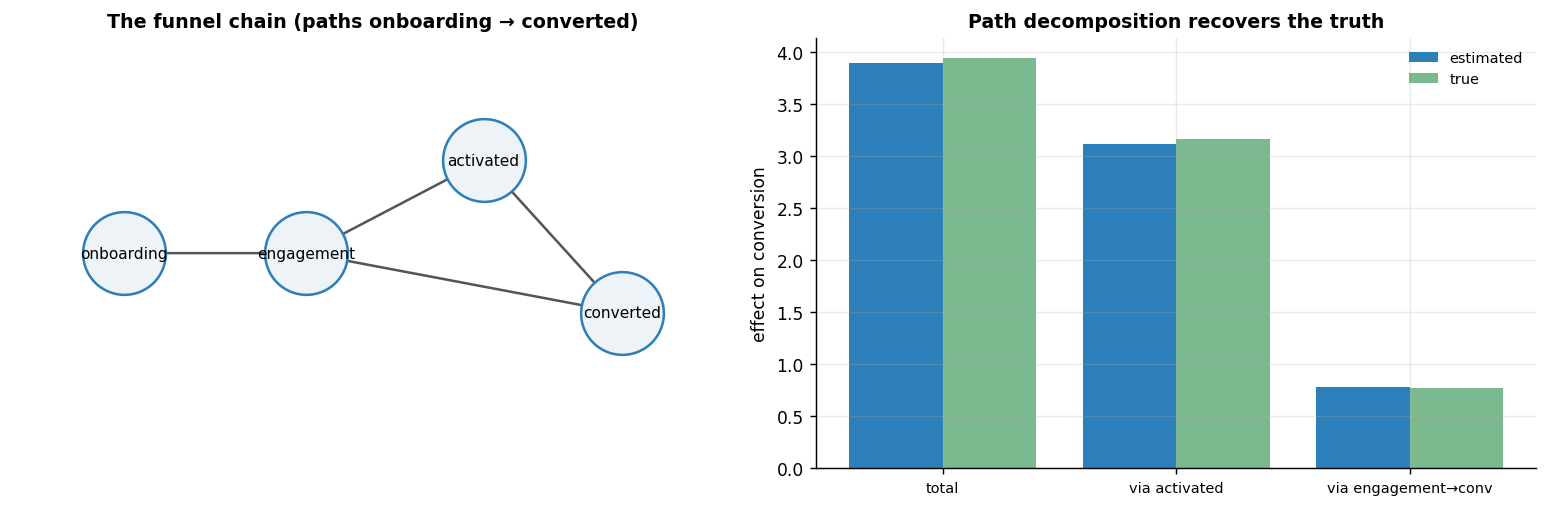

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
pos = {"onboarding": (0.05,0.5), "engagement": (0.38,0.5), "activated": (0.7,0.78), "converted": (0.95,0.32)}
edges = [("onboarding","engagement"),("engagement","activated"),("activated","converted"),("engagement","converted")]
plots.draw_dag(ax[0], pos, edges, title="The funnel chain (paths onboarding → converted)")
labels = ["total","via activated","via engagement→conv"]
means = [total_d.mean(), via_act.mean(), via_eng.mean()]
truths = [true_effects['total'], true_effects['indirect_via_engagement_activated'], true_effects['indirect_via_engagement_only']]
x = np.arange(len(labels))
ax[1].bar(x-0.2, means, 0.4, color=plots.BLUE, label="estimated")
ax[1].bar(x+0.2, truths, 0.4, color=plots.GREEN, alpha=0.6, label="true")
ax[1].set_xticks(x); ax[1].set_xticklabels(labels, fontsize=8); ax[1].legend(frameon=False, fontsize=8)
ax[1].set_ylabel("effect on conversion"); ax[1].set_title("Path decomposition recovers the truth")
fig.tight_layout()

## 6 · Decide, in euros — leverage ranking *and* its fragility

Two moves. First, **rank levers** by the € of conversion value from a unit improvement in each
stage's input (using the total downstream effect — onboarding's leverage cascades). Second, the
honest part: **sensitivity of the mediation split to unmeasured $M\!-\!Y$ confounding.** If an
omitted trait drives both engagement and conversion, the indirect path is over-credited — we
sweep a confounding strength and show how far the "invest in onboarding vs engagement" call
would have to be pushed before it flips.


     lever  €/unit  P(>0)
onboarding   467.0    1.0
engagement   217.0    1.0
 activated   107.0    1.0

Onboarding leads on leverage, and the call is ROBUST: even the strongest M–Y confounding we
swept (ρ=1.5) doesn't close the €250 gap to engagement.


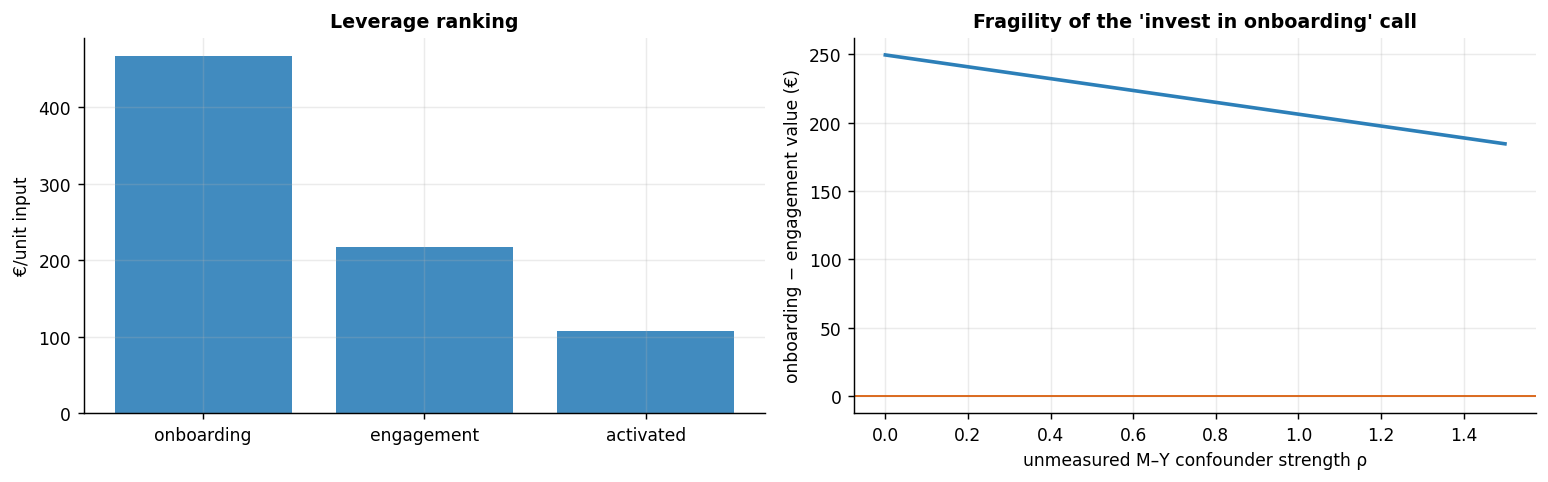

In [6]:
VALUE = 120.0
levers = {"onboarding": total_d, "engagement": get_draws(m.ate("converted","engagement")),
          "activated": get_draws(m.ate("converted","activated"))}
rows = [{"lever": k, "€/unit": round(v.mean()*VALUE,0), "P(>0)": round((v>0).mean(),2)} for k,v in levers.items()]
tbl = pd.DataFrame(rows).sort_values("€/unit", ascending=False)

# sensitivity: bias the M-Y (engagement->converted) coefficient by an unobserved confounder of
# strength rho, and see how the indirect share and the onboarding-vs-engagement gap move.
rho = np.linspace(0, 1.5, 16)
c_eng = idata.posterior["beta_converted"].sel(converted_predictors="engagement").values.mean()
onb, eng = total_d.mean()*VALUE, levers["engagement"].mean()*VALUE
gap = [(onb) - (eng + r*abs(c_eng)*VALUE) for r in rho]     # confounding inflates apparent engagement value
tip = rho[np.argmax(np.array(gap) < 0)] if np.any(np.array(gap) < 0) else np.nan

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].bar(tbl["lever"], tbl["€/unit"], color=plots.BLUE, alpha=0.9); ax[0].set_ylabel("€/unit input"); ax[0].set_title("Leverage ranking")
ax[1].plot(rho, gap, color=plots.BLUE, lw=2); ax[1].axhline(0, color=plots.ORANGE, lw=1)
if not np.isnan(tip): ax[1].axvline(tip, color=plots.ORANGE, ls=":"); ax[1].text(tip, max(gap)*0.5, f" flips at ρ≈{tip:.2f}", fontsize=8, color=plots.ORANGE)
ax[1].set_xlabel("unmeasured M–Y confounder strength ρ"); ax[1].set_ylabel("onboarding − engagement value (€)")
ax[1].set_title("Fragility of the 'invest in onboarding' call"); fig.tight_layout()
print(tbl.to_string(index=False))
if np.isnan(tip):
    print(f"\nOnboarding leads on leverage, and the call is ROBUST: even the strongest M–Y confounding we\n"
          f"swept (ρ={rho[-1]:.1f}) doesn't close the €{onb-eng:,.0f} gap to engagement.")
else:
    print(f"\nOnboarding leads on leverage; the call would flip toward engagement only if an unmeasured\n"
          f"engagement–conversion confounder of strength ρ≈{tip:.2f} were present. Judge if that's plausible.")

## 7 · Caveats

- **Natural effects lean on strong assumptions** — no unmeasured confounding of any of the three
  links plus the cross-world condition. Step 6 quantified how much $M\!-\!Y$ confounding would
  flip the decision; the point estimate alone hides that fragility.
- **Don't control away the mechanism.** The goal is to *decompose* the path; adjusting for a
  mediator when you wanted the total effect removes the very thing you're pricing (nb 05).
- **Linear-SCM decomposition is exact only if the SCM is linear.** For strong nonlinearities lean
  on `pathmc`'s simulate-through-the-graph numbers, not hand-multiplied coefficients.
